# Binaries NGC 1783

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

%matplotlib widget

In [2]:
input_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/ngc1783_catalog.csv'
df = pd.read_csv(input_file)

# rename columns of the filters
df.rename(columns={'F275Wu':'F275W', 'F336Wu':'F336W', 'F343Nu':'F343N', 'F435Wa':'F435W', 'F555Wa':'F555W', 'F814Wa':'F814W'}, inplace=True)

print(df)

             Xpos       Ypos    F275W  e_F275Wu  o_F275Wu  n_F275Wu  q_F275Wu  \
0       5090.7178  1271.4926      NaN       NaN         0         0         0   
1       5099.0498  1303.9301      NaN       NaN         0         0         0   
2       5107.5757  1313.3196      NaN       NaN         0         0         0   
3       5110.5039  1305.3313      NaN       NaN         0         0         0   
4       5118.0532  1320.9412      NaN       NaN         0         0         0   
...           ...        ...      ...       ...       ...       ...       ...   
247361  6228.8184  6196.5352      NaN       NaN         6         0         0   
247362  3985.0969  5295.8145  24.6808    0.0712         4         2         1   
247363  4880.4912  4396.8486      NaN       NaN         6         0         0   
247364  3949.7500  7996.6250      NaN       NaN         2         0         0   
247365  8458.8281  4394.2710      NaN       NaN         0         0         0   

          F336W  e_F336Wu  

In [3]:
data = df[(df['q_F275Wu'] == 1) &
          (df['q_F336Wu'] == 1) &
          (df['q_F343Nu'] == 1) &
          (df['q_F435Wa'] == 1) &
          (df['q_F555Wa'] == 1) &
          (df['q_F814Wa'] == 1)
]

In [4]:
# center and approximative radius of the cluster
center_1783 = np.array([5000,5500])
radius_1783 = 700

# center and radius of the reference field
center_ref = np.array([3750,6250])
radius_ref = 400

data['distance_1783'] = np.sqrt((data['Xpos']-center_1783[0])**2 + (data['Ypos']-center_1783[1])**2)
data['distance_reference'] = np.sqrt((data['Xpos']-center_ref[0])**2 + (data['Ypos']-center_ref[1])**2)

data_1783 = data[data['distance_1783'] < radius_1783]
data_ref = data[data['distance_reference'] < radius_ref]


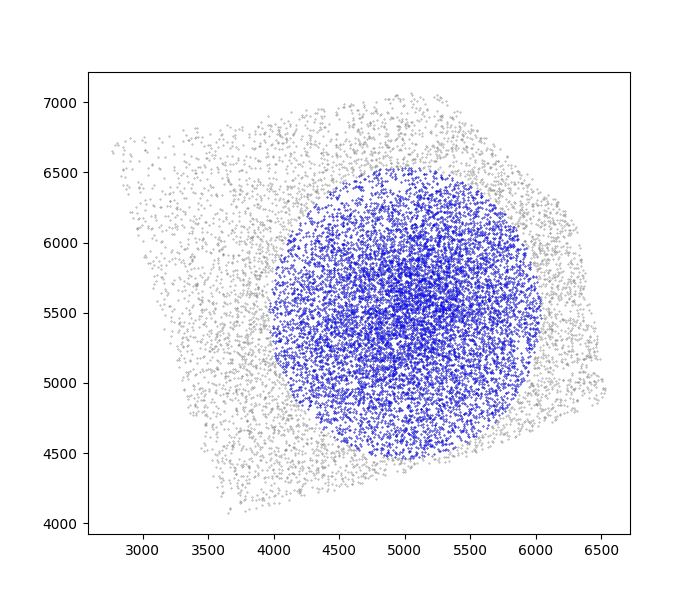

In [5]:
# to consider stars inside the half mass radius
half_mass_radius = True

if half_mass_radius == True: 
    data_all = data.copy()

    # convert in pixels the minimum radius in arcmin
    R_min = 41                          # arcsec
    image_scale = 0.0395                # arcsec/pixel 
    R_min = R_min / image_scale         # pixels

    radius_1783 = R_min

    # identify the center of the cluster
    X_center, Y_center = 5000, 5500

    # exclude the center of the cluster (data that are inside R_min)
    data = data[(data['Xpos']-X_center)**2 + (data['Ypos']-Y_center)**2 < R_min**2]

    # print the spatial distribution of the data
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(data_all['Xpos'], data_all['Ypos'], s=0.1, c='grey')
    ax.scatter(data['Xpos'], data['Ypos'], s=0.1, c='blue')
    plt.show()

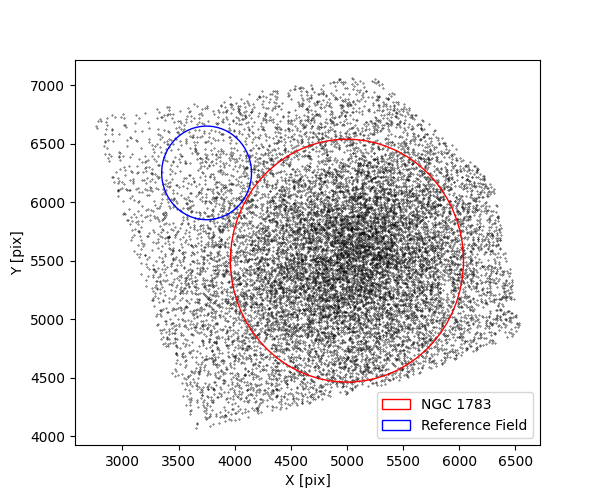

In [6]:
plt.figure(figsize=(6,5))

plt.scatter(data_all['Xpos'], data_all['Ypos'], s=0.1, c='black')
circle_1783 = plt.Circle((center_1783[0], center_1783[1]), radius_1783, color='red', fill=False, label='NGC 1783')
plt.gca().add_artist(circle_1783)
circle_ref = plt.Circle((center_ref[0], center_ref[1]), radius_ref, color='blue', fill=False, label='Reference Field')
plt.gca().add_artist(circle_ref)

plt.xlabel('X [pix]')
plt.ylabel('Y [pix]')
plt.legend()

plt.show()


In [7]:
import sys
import os

# set path to tools folder
module_path = '/Users/giadaaggio/Desktop/Thesis/TOTORO/CODES/tools'
sys.path.append(module_path)

from binaries_utils import BinaryStarUtils
binary = BinaryStarUtils()

colormap = plt.cm.jet

In [8]:
test_stars = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/test_stars_NGC1783.csv', delim_whitespace=True)

test_stars['index'] = test_stars.index
color_test = binary.color_index(test_stars, 'index', colormap)

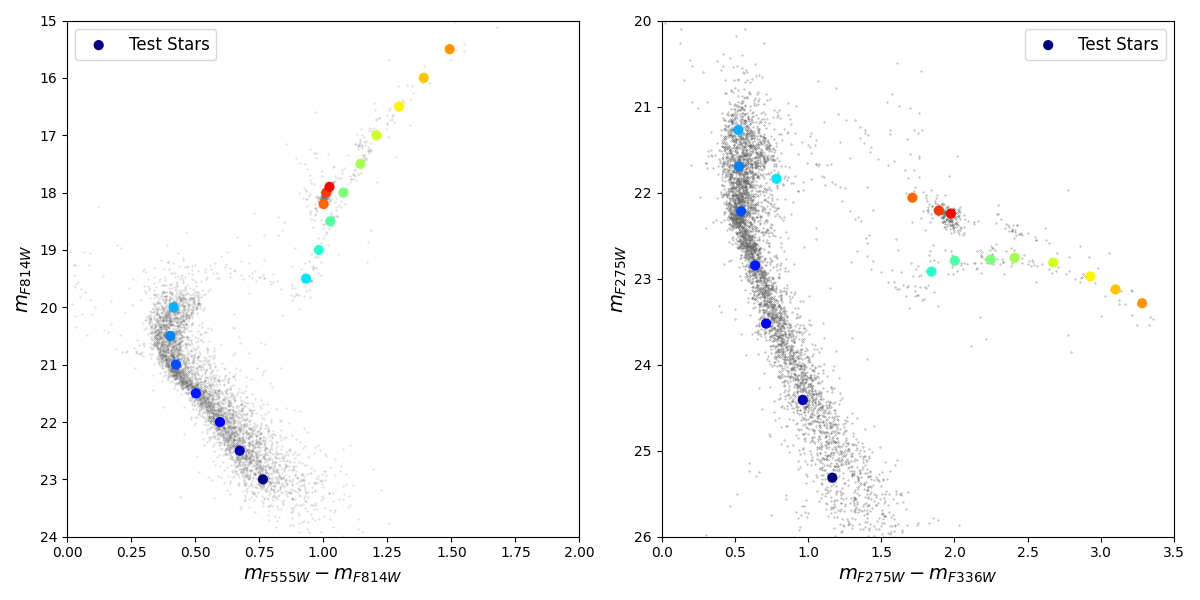

In [36]:
plt.figure(figsize=(12,6))

# Optical CMD
plt.subplot(1,2,1)

plt.scatter(data_1783['F555W']-data_1783['F814W'], data_1783['F814W'], s=0.1, c='dimgray', alpha=0.4, zorder=1)
plt.scatter(test_stars['F555W']-test_stars['F814W'], test_stars['F814W'], s=40, marker='o', c=color_test, label='Test Stars', zorder=2)
plt.gca().invert_yaxis()

plt.xlim(0,2.)
plt.ylim(24,15)

plt.xlabel(r'$m_{F555W}-m_{F814W}$', fontsize=14)
plt.ylabel(r'$m_{F814W}$', fontsize=14)
plt.legend(fontsize=12)

# UV CMD
plt.subplot(1,2,2)

plt.scatter(data_1783['F275W']-data_1783['F336W'], data_1783['F275W'], s=0.1, c='dimgray', alpha=0.8, zorder=1)
plt.scatter(test_stars['F275W']-test_stars['F336W'], test_stars['F275W'], s=40, marker='o', c=color_test, label='Test Stars', zorder=2)
plt.gca().invert_yaxis()

plt.xlim(0,3.5)
plt.ylim(26,20)

plt.xlabel(r'$m_{F275W}-m_{F336W}$', fontsize=14)
plt.ylabel(r'$m_{F275W}$', fontsize=14)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
hb_stars_index = test_stars.index[test_stars['source'] == 'HB_test_stars'].tolist()

hb_stars = test_stars.iloc[hb_stars_index]

In [11]:
# binaries in the optical filters
binaries_vis = binary.binary_system_HB(test_stars, hb_stars_index, 'F555W', 'F814W')
color_vis = binary.color_index(binaries_vis, 'secondary', colormap)

# binaries in the UV filters
binaries_uv = binary.binary_system_HB(test_stars, hb_stars_index, 'F275W', 'F336W')
color_uv = binary.color_index(binaries_uv, 'secondary', colormap)

#binaries_vis.to_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/BS_HB_vis.csv', index=False, float_format='%.4f', sep=' ')
#binaries_uv.to_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/BS_HB_uv.csv', index=False, float_format='%.4f', sep=' ')

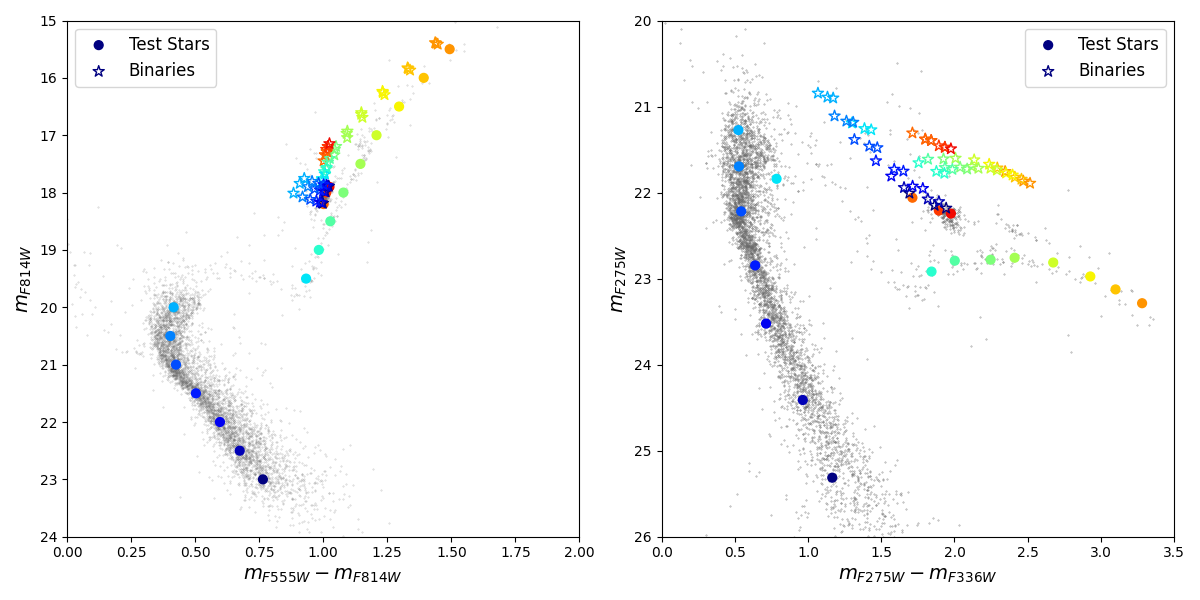

In [39]:
plt.figure(figsize=(12,6))

# Optical CMD
plt.subplot(1,2,1)

plt.scatter(data_1783['F555W']-data_1783['F814W'], data_1783['F814W'], s=0.1, c='dimgray', alpha=0.4, zorder=1)
plt.scatter(test_stars['F555W']-test_stars['F814W'], test_stars['F814W'], s=40, marker='o', c=color_test, zorder=2, label='Test Stars')
plt.scatter(binaries_vis['F555W']-binaries_vis['F814W'], binaries_vis['F814W'], s=70, marker='*', edgecolor=color_vis, facecolor='none', zorder=3, label='Binaries')
plt.gca().invert_yaxis()

plt.xlim(0,2.)
plt.ylim(24,15)

plt.legend(fontsize=12)
plt.xlabel(r'$m_{F555W}-m_{F814W}$', fontsize=14)
plt.ylabel(r'$m_{F814W}$', fontsize=14)

# UV CMD
plt.subplot(1,2,2)

plt.scatter(data_1783['F275W']-data_1783['F336W'], data_1783['F275W'], s=0.1, c='dimgray', alpha=0.8, zorder=1)
plt.scatter(test_stars['F275W']-test_stars['F336W'], test_stars['F275W'], s=40, marker='o', c=color_test, zorder=2, label='Test Stars')
plt.scatter(binaries_uv['F275W']-binaries_uv['F336W'], binaries_uv['F275W'], s=70, marker='*', edgecolor=color_uv, facecolor='none', zorder=3, label='Binaries')
plt.gca().invert_yaxis()

plt.xlim(0,3.5)
plt.ylim(26,20)

plt.legend(fontsize=12)
plt.xlabel(r'$m_{F275W}-m_{F336W}$', fontsize=14)
plt.ylabel(r'$m_{F275W}$', fontsize=14)

plt.tight_layout()
plt.show()

## Quantitative analysis of HB binaries
### Optical CMD

In [13]:
# Do you need to select the regions?
region_selection = False

In [14]:
from CMDAnalyzer import CMDRegionSelector

In [15]:
if region_selection is True:
    cmd_select_vis = CMDRegionSelector(
        data = data_1783,
        color = data_1783['F555W'] - data_1783['F814W'],
        magnitude = data_1783['F814W'],
        x_label='F555W-F814W',
        y_label='F814W',
        output_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F555W_F814W.csv'
    )

In [16]:
region_vis = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F555W_F814W.csv')

region_vis_A = CMDRegionSelector.get_stars_inside_region(
    region_id = 0,
    data = data_1783, 
    color = data_1783['F555W']-data_1783['F814W'], 
    magnitude = data_1783['F814W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F555W_F814W.csv')

region_vis_B = CMDRegionSelector.get_stars_inside_region(
    region_id = 1,
    data = data_1783, 
    color = data_1783['F555W']-data_1783['F814W'], 
    magnitude = data_1783['F814W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F555W_F814W.csv')

# compute the error on the binary fraction
error_vis_A = np.sqrt(len(region_vis_A) - 1)
error_vis_B = np.sqrt(len(region_vis_B) - 1)

print('Region A: ', len(region_vis_A), '+/-', error_vis_A)
print('Region B: ', len(region_vis_B), '+/-', error_vis_B)

frac_HB_bin_vis = len(region_vis_B) / (len(region_vis_A) + len(region_vis_B))
err_HB_bin_vis = (np.sqrt(len(region_vis_B)**2 * error_vis_A**2 + len(region_vis_A)**2 * error_vis_B**2)) / ((len(region_vis_A) + len(region_vis_B))**2)

print('Binary fraction: ', frac_HB_bin_vis, '+/-', err_HB_bin_vis)

Region A:  203 +/- 14.212670403551895
Region B:  22 +/- 4.58257569495584
Binary fraction:  0.09777777777777778 +/- 0.019385790115590613


In [17]:
region_names = {
    0: 'Region A',
    1: 'Region B',
}

region_colors = {
    0: 'red',
    1: 'blue',
}

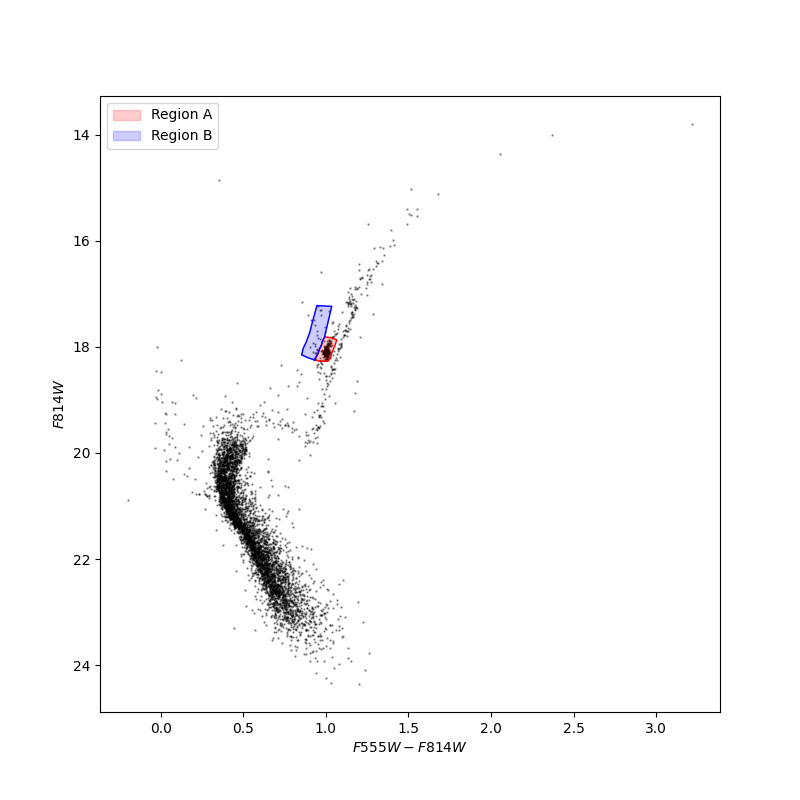

In [18]:
# Plot the CMD
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(data_1783['F555W'] - data_1783['F814W'], data_1783['F814W'], s=0.5, c='black', alpha=0.4, zorder=1)
ax.invert_yaxis()

ax.set_xlabel(r'$F555W-F814W$')
ax.set_ylabel(r'$F814W$')

# Group by Region_ID and plot each region
for region_id, region in region_vis.groupby("Region_ID"):
    # Append the first point to close the polygon
    closed_region = pd.concat([region, region.iloc[[0]]])
    region_label = region_names.get(region_id, f"Region {region_id}")  # Default to "Region X"

    # Fill the inside of the region
    ax.fill(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), alpha=0.2, label=region_label, zorder=2)

    # Plot the region outline
    ax.plot(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), linewidth=1, zorder=3)

# Add text to the plot using the value of the variable
ax.text(1.2, -11, f'Binary fraction = {frac_HB_bin_vis:.3f} $\pm$ {err_HB_bin_vis:.3f}', fontsize=10, color='blue')

ax.legend()
plt.show()

### UV CMD

In [19]:
if region_selection is True:
    cmd_select_vis = CMDRegionSelector(
        data = data_1783,
        color = data_1783['F275W'] - data_1783['F336W'],
        magnitude = data_1783['F275W'],
        x_label='F275W-F336W',
        y_label='F275W',
        output_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F275W_F336W.csv'
    )

In [20]:
region_uv = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F275W_F336W.csv')

region_uv_A = CMDRegionSelector.get_stars_inside_region(
    region_id = 0,
    data = data_1783, 
    color = data_1783['F275W']-data_1783['F336W'], 
    magnitude = data_1783['F275W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F275W_F336W.csv')

region_uv_B = CMDRegionSelector.get_stars_inside_region(
    region_id = 1,
    data = data_1783, 
    color = data_1783['F275W']-data_1783['F336W'], 
    magnitude = data_1783['F275W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F275W_F336W.csv')

# compute the error on the binary fraction
error_uv_A = np.sqrt(len(region_uv_A) - 1)
error_uv_B = np.sqrt(len(region_uv_B) - 1)

print('Region A: ', len(region_uv_A), '+/-', error_uv_A)
print('Region B: ', len(region_uv_B), '+/-', error_uv_B)

frac_HB_bin_uv = len(region_uv_B) / (len(region_uv_A) + len(region_uv_B))
err_HB_bin_uv = (np.sqrt(len(region_uv_B)**2 * error_uv_A**2 + len(region_uv_A)**2 * error_uv_B**2)) / ((len(region_uv_A) + len(region_uv_B))**2)

print('Binary fraction: ', frac_HB_bin_uv, '+/-', err_HB_bin_uv)

Region A:  202 +/- 14.177446878757825
Region B:  24 +/- 4.795831523312719
Binary fraction:  0.10619469026548672 +/- 0.02010289637703173


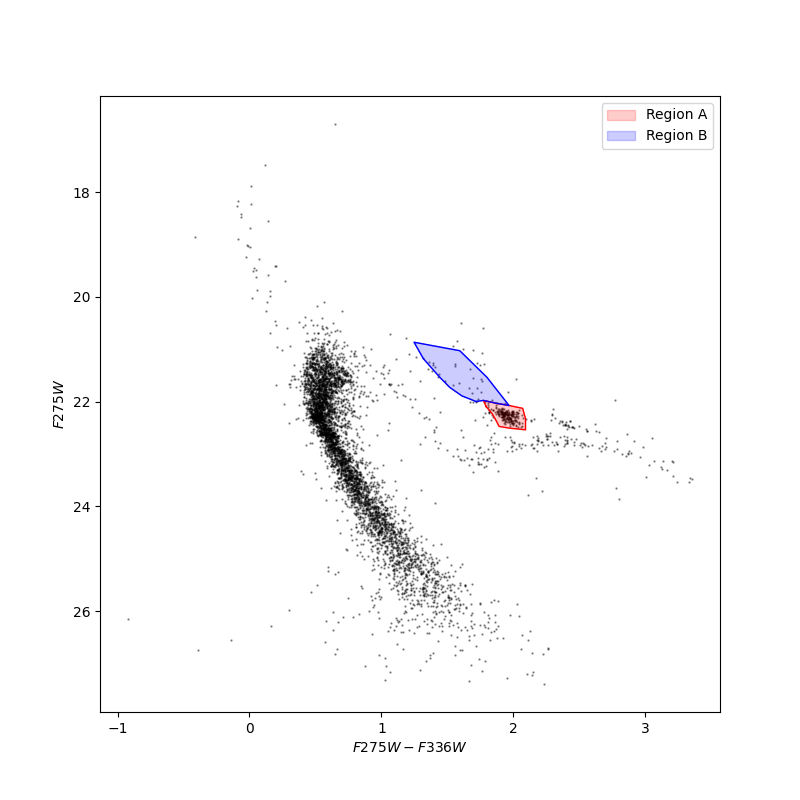

In [21]:
# Plot the CMD
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(data_1783['F275W'] - data_1783['F336W'], data_1783['F275W'], s=0.5, c='black', alpha=0.4, zorder=1)
ax.invert_yaxis()
ax.set_xlabel(r'$F275W-F336W$')
ax.set_ylabel(r'$F275W$')

# Group by Region_ID and plot each region
for region_id, region in region_uv.groupby("Region_ID"):
    # Append the first point to close the polygon
    closed_region = pd.concat([region, region.iloc[[0]]])
    region_label = region_names.get(region_id, f"Region {region_id}")  # Default to "Region X"

    # Fill the inside of the region
    ax.fill(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), alpha=0.2, label=region_label, zorder=2)

    # Plot the region outline
    ax.plot(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), linewidth=1, zorder=3)

# Add text to the plot using the value of the variable
ax.text(2, -9, f'Binary fraction = {frac_HB_bin_uv:.3f}', fontsize=10, color='blue')

ax.legend()
plt.show()

### Clean up from AGB stars

In [22]:
if region_selection is True:
    agb_region_selection = CMDRegionSelector(
        data = data_1783,
        color = data_1783['F275W'] - data_1783['F814W'],
        magnitude = data_1783['F336W'],
        x_label='F275W-F814W',
        y_label='F336W',
        output_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/agb_F275W_F336W.csv'
    )

In [23]:
agb_region = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/agb_F275W_F336W.csv'
agb_stars = CMDRegionSelector.get_stars_inside_region(0, data_1783, data_1783['F275W']-data_1783['F814W'], data_1783['F336W'], agb_region)

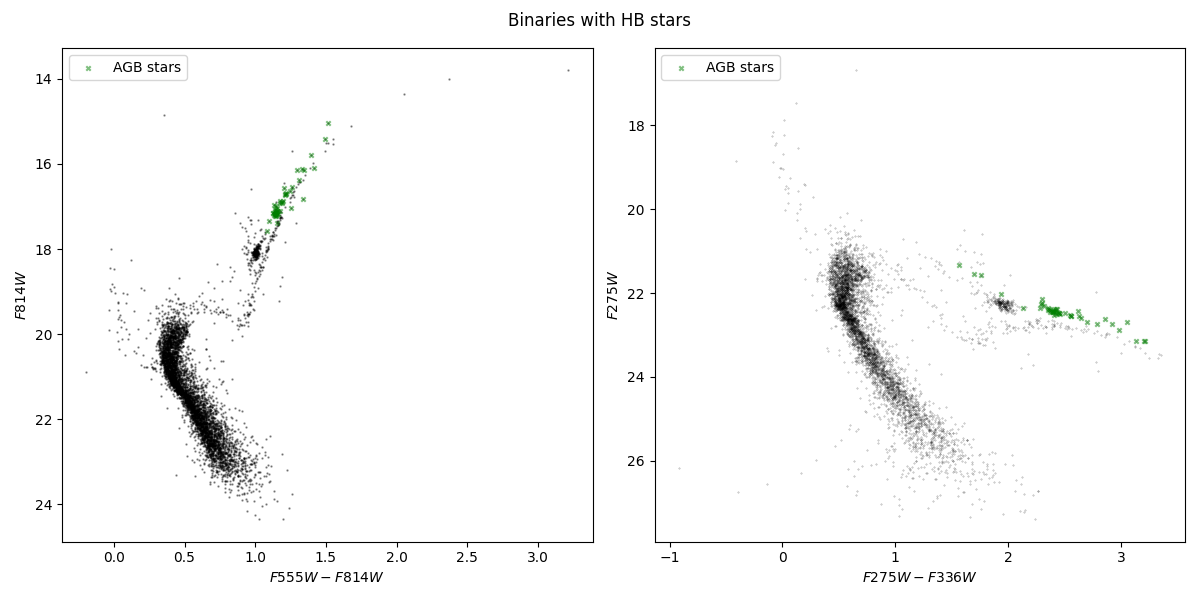

In [24]:
plt.figure(figsize=(12, 6))

# plot optical filters
plt.subplot(1, 2, 1)

plt.scatter(data_1783['F555W']-data_1783['F814W'], data_1783['F814W'], s=0.5, c='black', alpha=0.4, zorder=1)
plt.scatter(agb_stars['F555W']-agb_stars['F814W'], agb_stars['F814W'], s=10, alpha=0.5, c='green', label='AGB stars', marker='x', zorder=2)
plt.gca().invert_yaxis()


plt.xlabel(r'$F555W-F814W$')
plt.ylabel(r'$F814W$')
plt.legend(loc='upper left')

# plot UV filters
plt.subplot(1, 2, 2)

plt.scatter(data_1783['F275W']-data_1783['F336W'], data_1783['F275W'], s=0.1, c='black', alpha=0.4, zorder=1)
plt.scatter(agb_stars['F275W']-agb_stars['F336W'], agb_stars['F275W'], s=10, alpha=0.5, c='green', label='AGB stars', marker='x', zorder=2)
plt.gca().invert_yaxis()


plt.xlabel(r'$F275W-F336W$')
plt.ylabel(r'$F275W$')
plt.legend(loc='upper left')

plt.suptitle('Binaries with HB stars')
plt.tight_layout()
plt.show()

In [25]:
# recompute the binary fraction in the selected regions without counting the AGB stars
region_vis_B_noagb = region_vis_B[~region_vis_B.index.isin(agb_stars.index)]
error_vis_B_noagb = np.sqrt(len(region_vis_B_noagb) - 1)

frac_HB_bin_vis_noagb = len(region_vis_B_noagb) / (len(region_vis_A) + len(region_vis_B_noagb))
print('Binary fraction (no AGB)')
print('Visible:', frac_HB_bin_vis_noagb)

region_uv_B_noagb = region_uv_B[~region_uv_B.index.isin(agb_stars.index)]
error_uv_B_noagb = np.sqrt(len(region_uv_B_noagb) - 1)

frac_HB_bin_uv_noagb = len(region_uv_B_noagb) / (len(region_uv_A) + len(region_uv_B_noagb))
print('UV:', frac_HB_bin_uv_noagb)

Binary fraction (no AGB)
Visible: 0.09777777777777778
UV: 0.09009009009009009


### Clean up from stars in the field

In [26]:
region_vis_A_field = CMDRegionSelector.get_stars_inside_region(
    region_id = 0,
    data = data_ref, 
    color = data_ref['F555W']-data_ref['F814W'], 
    magnitude = data_ref['F814W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F555W_F814W.csv')

region_vis_B_field = CMDRegionSelector.get_stars_inside_region(
    region_id = 1,
    data = data_ref, 
    color = data_ref['F555W']-data_ref['F814W'], 
    magnitude = data_ref['F814W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F555W_F814W.csv')

err_visA_field = np.sqrt(len(region_vis_A_field) - 1)
err_visB_field = np.sqrt(len(region_vis_B_field) - 1)

print('Region A: ', len(region_vis_A_field), '+/-', err_visA_field)
print('Region B: ', len(region_vis_B_field), '+/-', err_visB_field)

Region A:  4 +/- 1.7320508075688772
Region B:  1 +/- 0.0


In [27]:
region_uv_A_field = CMDRegionSelector.get_stars_inside_region(
    region_id = 0,
    data = data_ref, 
    color = data_ref['F275W']-data_ref['F336W'], 
    magnitude = data_ref['F275W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F275W_F336W.csv')

region_uv_B_field = CMDRegionSelector.get_stars_inside_region(
    region_id = 1,
    data = data_ref, 
    color = data_ref['F275W']-data_ref['F336W'], 
    magnitude = data_ref['F275W'], 
    regions_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/regions_HB_F275W_F336W.csv')

err_uvA_field = np.sqrt(len(region_uv_A_field) - 1)
err_uvB_field = np.sqrt(len(region_uv_B_field) - 1)

print('Region A: ', len(region_uv_A_field), '+/-', err_uvA_field)
print('Region B: ', len(region_uv_B_field), '+/-', err_uvB_field)

Region A:  4 +/- 1.7320508075688772
Region B:  0 +/- nan


In [28]:
frac_HB_bin_vis_clean = (len(region_vis_B_noagb) - len(region_vis_B_field)) / (len(region_vis_A) - len(region_vis_A_field) + len(region_vis_B_noagb)- len(region_vis_B_field))
print('Binary fraction (after cleaning from field stars) - vis:', frac_HB_bin_vis_clean)

frac_HB_bin_uv_clean = (len(region_uv_B_noagb) - len(region_uv_B_field)) / (len(region_uv_A) - len(region_uv_A_field) + len(region_uv_B_noagb)- len(region_uv_B_field))
print('Binary fraction (after cleaning from field stars) - uv:', frac_HB_bin_uv_clean)

Binary fraction (after cleaning from field stars) - vis: 0.09545454545454546
Binary fraction (after cleaning from field stars) - uv: 0.09174311926605505


In [29]:
# Define values and their uncertainties
N_A = len(region_vis_A)  # Number of stars in region A
N_A_field = len(region_vis_A_field)  # Number of field stars in region A
N_B_noagb = len(region_vis_B_noagb)  # Number of stars in region B (excluding AGB)
N_B_field = len(region_vis_B_field)  # Number of field stars in region B

# Define associated uncertainties (assuming Poisson errors)
dN_A = np.sqrt(N_A-1)
dN_A_field = np.sqrt(N_A_field-1)
dN_B_noagb = np.sqrt(N_B_noagb-1)
dN_B_field = np.sqrt(N_B_field-1)

# Compute A and B with their uncertainties
A = N_A - N_A_field
dA = np.sqrt(dN_A**2 + dN_A_field**2)  # Error propagation for A

B = N_B_noagb - N_B_field
dB = np.sqrt(dN_B_noagb**2 + dN_B_field**2)  # Error propagation for B

# Compute the fraction
frac_HB_bin_vis_clean = B / (A + B)

# Propagate the uncertainty
d_frac_HB_bin_vis_clean = np.sqrt((B**2 * dA**2 + A**2 * dB**2)) / (A + B)**2

# Print results
print(f"Fraction of binaries in visible: {frac_HB_bin_vis_clean:.4f} ± {d_frac_HB_bin_vis_clean:.4f}")

Fraction of binaries in visible: 0.0955 ± 0.0198


In [30]:
# Define values and their uncertainties
N_A = len(region_uv_A)  # Number of stars in region A
N_A_field = len(region_uv_A_field)  # Number of field stars in region A
N_B_noagb = len(region_uv_B_noagb)  # Number of stars in region B (excluding AGB)
N_B_field = len(region_uv_B_field)  # Number of field stars in region B

# Define associated uncertainties (assuming Poisson errors)
dN_A = np.sqrt(N_A)
dN_A_field = np.sqrt(N_A_field)
dN_B_noagb = np.sqrt(N_B_noagb)
dN_B_field = np.sqrt(N_B_field)

# Compute A and B with their uncertainties
A = N_A - N_A_field
dA = np.sqrt(dN_A**2 + dN_A_field**2)  # Error propagation for A

B = N_B_noagb - N_B_field
dB = np.sqrt(dN_B_noagb**2 + dN_B_field**2)  # Error propagation for B

# Compute the fraction
frac_HB_bin_uv_clean = B / (A + B)

# Propagate the uncertainty
d_frac_HB_bin_uv_clean = np.sqrt((B**2 * dA**2 + A**2 * dB**2)) / (A + B)**2

# Print results
print(f"Fraction: {frac_HB_bin_uv_clean:.4f} ± {d_frac_HB_bin_uv_clean:.4f}")

Fraction: 0.0917 ± 0.0196


## Final results

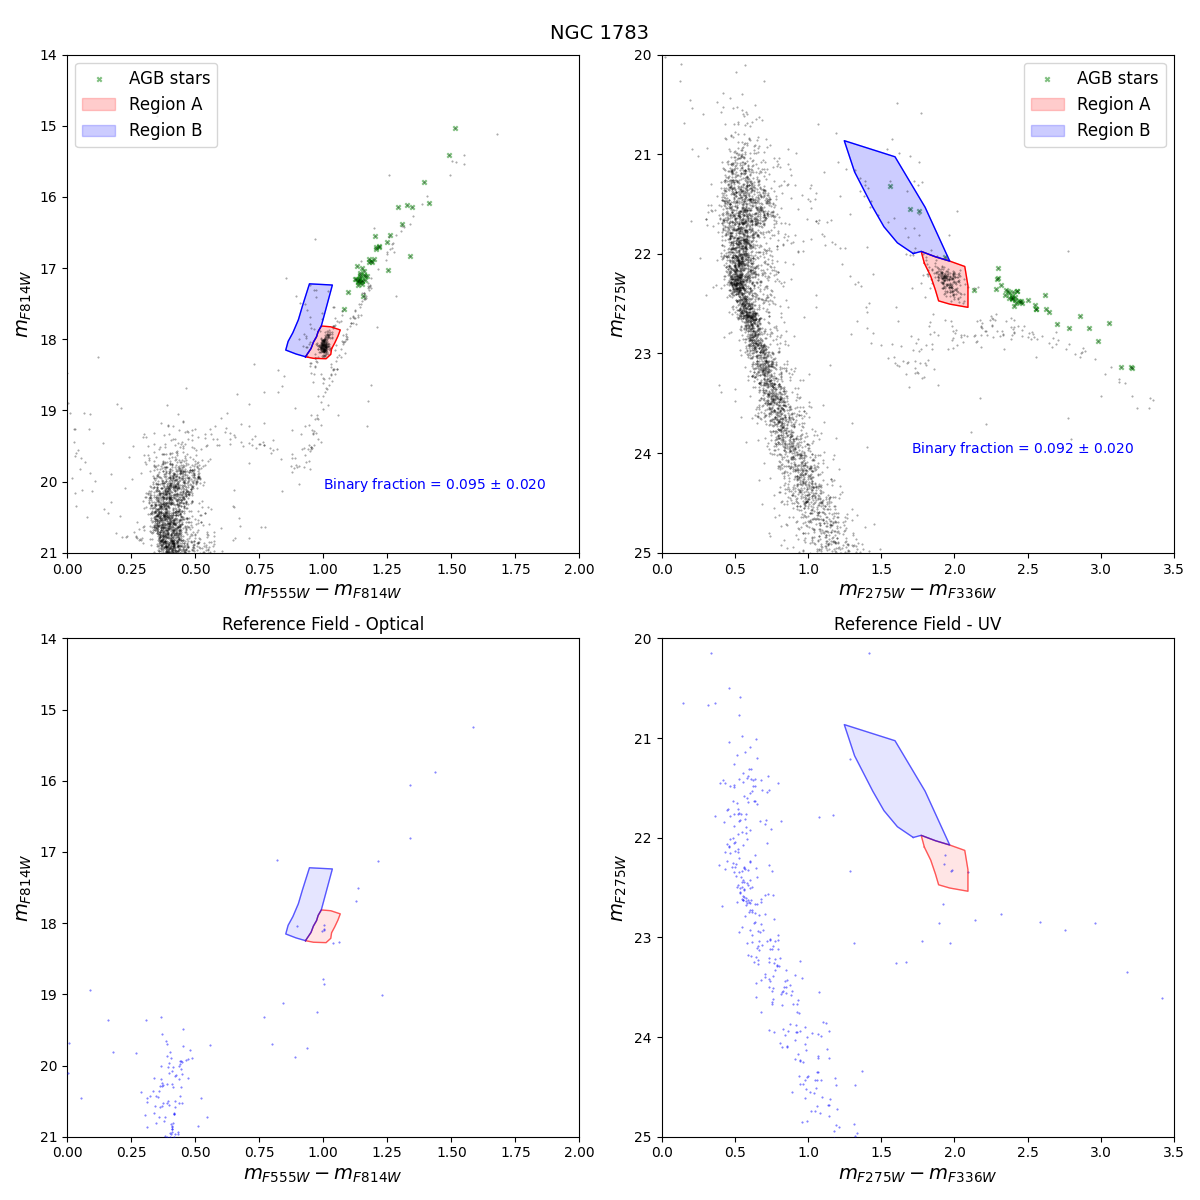

In [46]:
# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2 rows, 2 columns

# First CMD plot
ax1 = axes[0, 0]
scatter1 = ax1.scatter(data_1783['F555W'] - data_1783['F814W'], data_1783['F814W'], s=0.2, c='black', alpha=0.4, zorder=3)
ax1.scatter(agb_stars['F555W'] - agb_stars['F814W'], agb_stars['F814W'], s=10, c='green', alpha=0.5, zorder=2, marker='x', label='AGB stars')
ax1.invert_yaxis()
ax1.set_xlim(0, 2.0)
ax1.set_ylim(21,14)
ax1.set_xlabel(r'$m_{F555W}-m_{F814W}$', fontsize=14)
ax1.set_ylabel(r'$m_{F814W}$', fontsize=14)

# Plot regions for first CMD
for region_id, region in region_vis.groupby("Region_ID"):
    closed_region = pd.concat([region, region.iloc[[0]]])
    region_label = region_names.get(region_id, f"Region {region_id}")

    ax1.fill(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), alpha=0.2, label=region_label, zorder=2)
    ax1.plot(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), linewidth=1, zorder=3)

# Add text annotation
ax1.text(1.0, 20.1, f'Binary fraction = {frac_HB_bin_vis_clean:.3f} $\pm$ {d_frac_HB_bin_vis_clean:.3f}', fontsize=10, color='blue')
ax1.legend(loc='upper left', fontsize=12)

# Second CMD plot
ax2 = axes[0, 1]
scatter2 = ax2.scatter(data_1783['F275W'] - data_1783['F336W'], data_1783['F275W'], s=0.2, c='black', alpha=0.4, zorder=3)
ax2.scatter(agb_stars['F275W'] - agb_stars['F336W'], agb_stars['F275W'], s=10, c='green', alpha=0.5, zorder=2, marker='x', label='AGB stars')
ax2.invert_yaxis()
ax2.set_xlim(0, 3.5)
ax2.set_ylim(25,20)
ax2.set_xlabel(r'$m_{F275W}-m_{F336W}$', fontsize=14)
ax2.set_ylabel(r'$m_{F275W}$', fontsize=14)

# Plot regions for second CMD
for region_id, region in region_uv.groupby("Region_ID"):
    closed_region = pd.concat([region, region.iloc[[0]]])
    region_label = region_names.get(region_id, f"Region {region_id}")

    ax2.fill(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), alpha=0.2, label=region_label, zorder=2)
    ax2.plot(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), linewidth=1, zorder=3)

# Add text annotation
ax2.text(1.7, 24, f'Binary fraction = {frac_HB_bin_uv_clean:.3f} $\pm$ {d_frac_HB_bin_uv_clean:.3f}', fontsize=10, color='blue')
ax2.legend(loc='upper right', fontsize=12)

# optical reference field
ax3 = axes[1, 0]
scatter3 = ax3.scatter(data_ref['F555W'] - data_ref['F814W'], data_ref['F814W'], s=0.2, c='blue', zorder=3, alpha=0.6)
ax3.invert_yaxis()
ax3.set_xlim(0, 2.0)
ax3.set_ylim(21,14)
ax3.set_xlabel(r'$m_{F555W}-m_{F814W}$', fontsize=14)
ax3.set_ylabel(r'$m_{F814W}$', fontsize=14)
ax3.set_title("Reference Field - Optical", fontsize=12)

# Plot regions for first CMD
for region_id, region in region_vis.groupby("Region_ID"):
    closed_region = pd.concat([region, region.iloc[[0]]])
    region_label = region_names.get(region_id, f"Region {region_id}")

    ax3.fill(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), alpha=0.1, label=region_label, zorder=2)
    ax3.plot(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), linewidth=1, alpha=0.6, zorder=3)

# UV reference field
ax4 = axes[1, 1]
scatter4 = ax4.scatter(data_ref['F275W'] - data_ref['F336W'], data_ref['F275W'], s=0.2, c='blue', zorder=3, alpha=0.6)
ax4.invert_yaxis()
ax4.set_xlim(0, 3.5)
ax4.set_ylim(25,20)
ax4.set_xlabel(r'$m_{F275W}-m_{F336W}$', fontsize=14)
ax4.set_ylabel(r'$m_{F275W}$', fontsize=14)
ax4.set_title("Reference Field - UV", fontsize=12)

# Plot regions for second CMD
for region_id, region in region_uv.groupby("Region_ID"):
    closed_region = pd.concat([region, region.iloc[[0]]])
    region_label = region_names.get(region_id, f"Region {region_id}")

    ax4.fill(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), alpha=0.1, label=region_label, zorder=2)
    ax4.plot(closed_region["X"], closed_region["Y"], color=region_colors.get(region_id, "black"), linewidth=1, alpha=0.6, zorder=3)

# Adjust layout
plt.suptitle('NGC 1783', fontsize=14)
plt.tight_layout()
plt.show()


## Isochrones

In [32]:
isochrone = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/isochrone_NGC1783.dat', delim_whitespace=True, skiprows=13)
isochrone = isochrone.rename(columns={'F814Wmag': 'F814W', 'F555Wmag': 'F555W'})

# distance modulus and color excess from Milone et al. 2023
distance_modulus = 18.51
color_excess = 0.03

# coefficients for the reddening correction 
R_I = 1.8420        # F814W
R_V = 3.2118        # F555W

# correct the isochrone
isochrone['F555W'] = isochrone['F555W'] + distance_modulus + color_excess * R_V
isochrone['F814W'] = isochrone['F814W'] + distance_modulus + color_excess * R_I

In [33]:
prim_for_ratio = test_stars[test_stars['index'] == 17]
sec_for_ratio = test_stars[test_stars['index'] == 4]

# find the mass of the primary star
magnitude_prim = prim_for_ratio['F814W'].values[0]
magnitude_sec = sec_for_ratio['F814W'].values[0]

In [34]:
# find the point in iso_pd that is closest to the magnitude of the primary star
# define a boundary on the color F555W-F814W
isochrone_HB = isochrone[(isochrone['F555W'] - isochrone['F814W'] < 1.02)]

idx_prim = (isochrone_HB['F814W']-magnitude_prim).abs().idxmin()
mass_prim = isochrone['Mini'].iloc[idx_prim]
print(mass_prim)

idx_sec = (isochrone['F814W']-magnitude_sec).abs().idxmin()
mass_sec = isochrone['Mini'].iloc[idx_sec]
print(mass_sec)

q_low = mass_sec/mass_prim
print('lowest q:', q_low)


1.5948557854
1.3007112741
lowest q: 0.8155667026494018


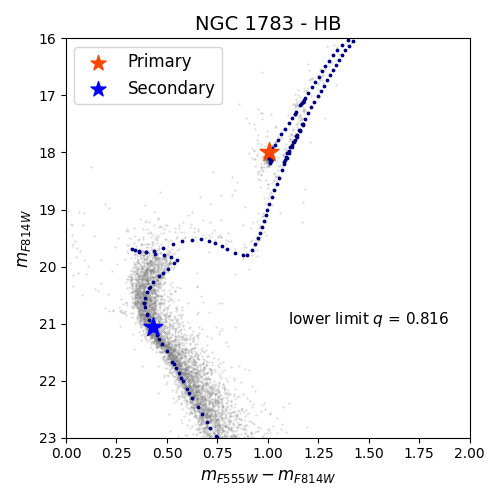

In [48]:
fig, ax1 = plt.subplots(figsize=(5,5))

ax1.scatter(data_1783['F555W'] - data_1783['F814W'], data_1783['F814W'], s=0.1, c='gray', alpha=0.5)
ax1.scatter(isochrone['F555W'] - isochrone['F814W'], isochrone['F814W'], s=3, c='navy')
ax1.scatter(isochrone['F555W'].iloc[idx_prim] - isochrone['F814W'].iloc[idx_prim], isochrone['F814W'].iloc[idx_prim], s=200, marker='*', c='orangered', label='Primary')
ax1.scatter(isochrone['F555W'].iloc[idx_sec] - isochrone['F814W'].iloc[idx_sec], isochrone['F814W'].iloc[idx_sec], s=200, marker='*', c='blue', label='Secondary')

ax1.set_xlim(0,2)
ax1.set_ylim(23,16)

ax1.set_xlabel(r'$m_{F555W} - m_{F814W}$', fontsize=12)
ax1.set_ylabel(r'$m_{F814W}$', fontsize=12)
ax1.legend(fontsize=12, markerscale=0.8, loc='upper left')
ax1.set_title('NGC 1783 - HB', fontsize=14)
ax1.text(1.10, 21, f'lower limit $q$ = {q_low:.3f}', fontsize=11, color='black')

plt.tight_layout()
plt.show()